In [1]:
# PROJECT 1: ANALYSIS

In [2]:
import pandas as pd

#import the data used
gold_data = pd.read_csv("Gold Futures Historical Data.csv", delimiter=';')
eurusd = pd.read_csv("EUR_USD Historical Data.csv", delimiter=';')
print(gold_data)
print(eurusd)

            Date     Price      Open      High       Low    Vol. Change %
0     06/15/2020  1,721.80  1,733.20  1,736.20  1,701.00   0.65K   -0.59%
1     06/12/2020  1,732.00  1,729.70  1,746.90  1,724.10   0.59K   -0.16%
2     06/11/2020  1,734.70  1,741.20  1,749.40  1,722.60   0.76K    1.12%
3     06/10/2020  1,715.50  1,715.10  1,743.60  1,709.00   1.15K   -0.09%
4     06/09/2020  1,717.00  1,699.20  1,724.10  1,694.40   0.62K    1.01%
...          ...       ...       ...       ...       ...     ...      ...
4995  01/10/2000    282.70    282.40    283.90    281.80  30.60K   -0.07%
4996  01/07/2000    282.90    282.50    284.50    282.00  11.27K    0.18%
4997  01/06/2000    282.40    281.60    282.80    280.20  19.06K    0.11%
4998  01/05/2000    282.10    283.70    285.00    281.00  25.45K   -0.56%
4999  01/04/2000    283.70    289.50    289.50    280.00  21.62K   -2.04%

[5000 rows x 7 columns]
            Date   Price    Open    High     Low  Vol. Change %
0     03/05/2019  1.130

In [3]:
print((eurusd.describe()))
print(gold_data.describe())

             Price         Open         High          Low  Vol.
count  5000.000000  5000.000000  5000.000000  5000.000000   0.0
mean      1.213581     1.213715     1.219377     1.207979   NaN
std       0.168854     0.168868     0.169397     0.168240   NaN
min       0.827000     0.827000     0.832600     0.822700   NaN
25%       1.114075     1.113900     1.118900     1.108000   NaN
50%       1.233300     1.233500     1.239000     1.227800   NaN
75%       1.335800     1.335725     1.340700     1.329200   NaN
max       1.598700     1.599600     1.603900     1.586500   NaN
              Date   Price    Open    High     Low    Vol. Change %
count         5000    5000    5000    5000    5000    4990     5000
unique        5000    3892    3820    3865    3840    4510      621
top     06/15/2020  278.60  266.00  275.00  274.00  39.58K    0.00%
freq             1       7       6       6       6       4       49


In [4]:
#Print the column names
print(eurusd.columns)
print(gold_data.columns)

Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')
Index(['Date', 'Price', 'Open', 'High', 'Low', 'Vol.', 'Change %'], dtype='object')


In [5]:

#No need to set 'Date' to numeric if data timelike
#Set 'Price' to numeric
gold_data['Price'] = pd.to_numeric(gold_data['Price'].replace(',', '', regex=True))
eurusd['Price'] = pd.to_numeric(eurusd['Price'].replace(',', '', regex=True))
#Set 'Date' to datetime and index so you can resample
gold_data['Date'] = pd.to_datetime(gold_data['Date'])
eurusd['Date'] = pd.to_datetime(eurusd['Date'])

#Set 'Date' as index
#gold_data = gold_data.set_index('Date')
#eurusd = eurusd.set_index('Date')

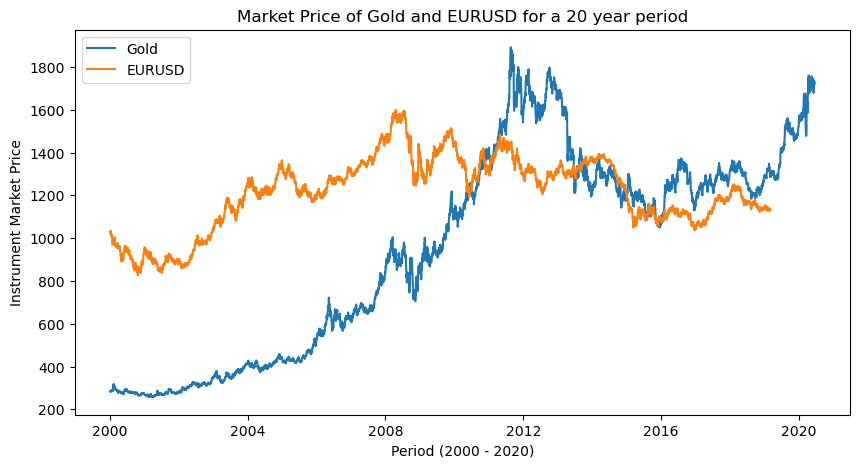

In [6]:
#Plot the date vs price
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 5))

plt.plot(gold_data['Date'], gold_data['Price'], label='Gold')
plt.plot(eurusd['Date'], eurusd['Price']*1000, label='EURUSD')
plt.xlabel("Period (2000 - 2020)")
plt.ylabel("Instrument Market Price")
plt.title("Market Price of Gold and EURUSD for a 20 year period")
plt.legend()

In [7]:
#Resample your data
#gold_monthly = gold_data.resample('M').mean(numeric_only=True)
#eurusd_monthly = eurusd.resample('M').mean(numeric_only=True)

#Group your data
gold_monthly = gold_data.groupby(pd.PeriodIndex(gold_data['Date'], freq="M"))['Price'].mean()
eurusd_monthly = eurusd.groupby(pd.PeriodIndex(eurusd['Date'], freq="M"))['Price'].mean()

In [8]:
gold_monthly

Date
2000-01     285.857895
2000-02     302.415000
2000-03     287.147826
2000-04     281.968421
2000-05     276.031818
              ...     
2020-02    1597.440000
2020-03    1596.654545
2020-04    1698.690476
2020-05    1721.214286
2020-06    1717.672727
Freq: M, Name: Price, Length: 246, dtype: float64

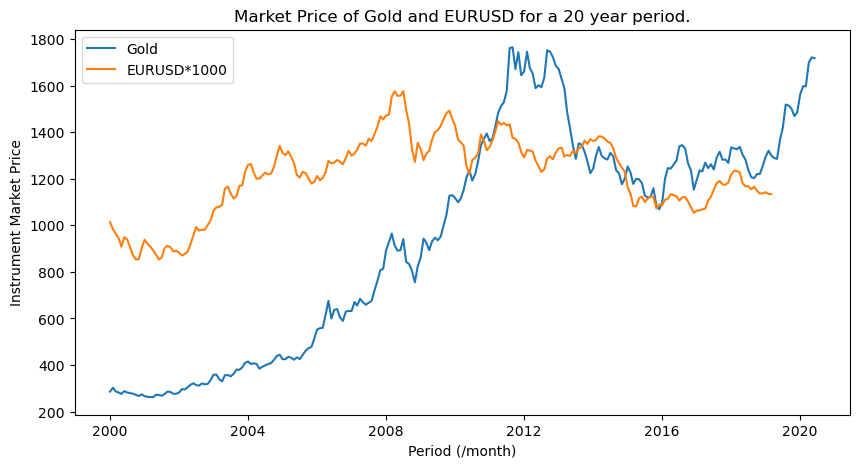

In [9]:
plt.figure(figsize=(10, 5))
plt.plot(gold_monthly.index.to_timestamp(), gold_monthly.values, label='Gold')
plt.plot(eurusd_monthly.index.to_timestamp(), eurusd_monthly.values*1000, label='EURUSD*1000')
plt.xlabel("Period (/month)")
plt.ylabel("Instrument Market Price")
plt.title("Market Price of Gold and EURUSD for a 20 year period.")
plt.legend()

In [10]:
# Combine both into one DataFrame
data = pd.concat([gold_monthly, eurusd_monthly], axis=1)
# Rename columns so you know which is which
data.columns = ['Gold', 'EURUSD']
data = data.dropna()
#data = data.reset_index()
data

,Gold,EURUSD
Date,,
2000-01,285.857895,1.013300
2000-02,302.415000,0.984267
2000-03,287.147826,0.964787
2000-04,281.968421,0.945100
2000-05,276.031818,0.908239
...,...,...
2018-11,1221.081250,1.136086
2018-12,1255.107143,1.137300
2019-01,1295.652941,1.141970


In [11]:
#Calculate the correlation
correlation = data[['Gold', 'EURUSD']].corr()
print(correlation)

            Gold    EURUSD
Gold    1.000000  0.491338
EURUSD  0.491338  1.000000


In [12]:
#Another way of calculating correlation between Gold and EURUSD
correlation = data['Gold'].corr(data['EURUSD'])
print(f"Correlation: {correlation:.2f}")

Correlation: 0.49


In [13]:
#### AI-generated text
#Arolling correlation is a "moving window" that calculates the relationship between two things (like Gold and EUR/USD) over a specific period, then slides that window forward day-by-day or month-by-month.
#Why use it?
#A single correlation number for 20 years (e.g., 0.8) tells you the average relationship. But it hides the truth: sometimes they move together perfectly, and sometimes they go in opposite directions.
#A rolling correlation reveals these "mood swings" in the market.
#How it works (The "Window" Concept):
#Imagine you have 20 years of monthly data and you choose a 12-month window:

 #   Step 1: The computer looks at Jan 2000 to Dec 2000. It calculates the correlation and puts a dot on the chart for Dec 2000.
  #  Step 2: The window slides forward one month. It looks at Feb 2000 to Jan 2001. It calculates a new correlation and puts a dot for Jan 2001.
   # Step 3: This repeats for every month until it reaches 2020.

#What the chart tells you:

 #   When the line is high (near 1.0): The relationship is strong. If the Euro went up, Gold almost certainly went up too.
  #  When the line is low (near -1.0): They are "anti-correlated." If the Euro went up, Gold crashed.
   # When the line is messy (near 0): There is no relationship. One is moving, and the other is just doing its own thing.

#Real-World Example: During a global financial crisis, both Gold and the Euro might spike because people are fleeing the US Dollar (High Positive Correlation). But during a European debt crisis, the Euro might crash while Gold stays high (Correlation drops to 0 or becomes negative).

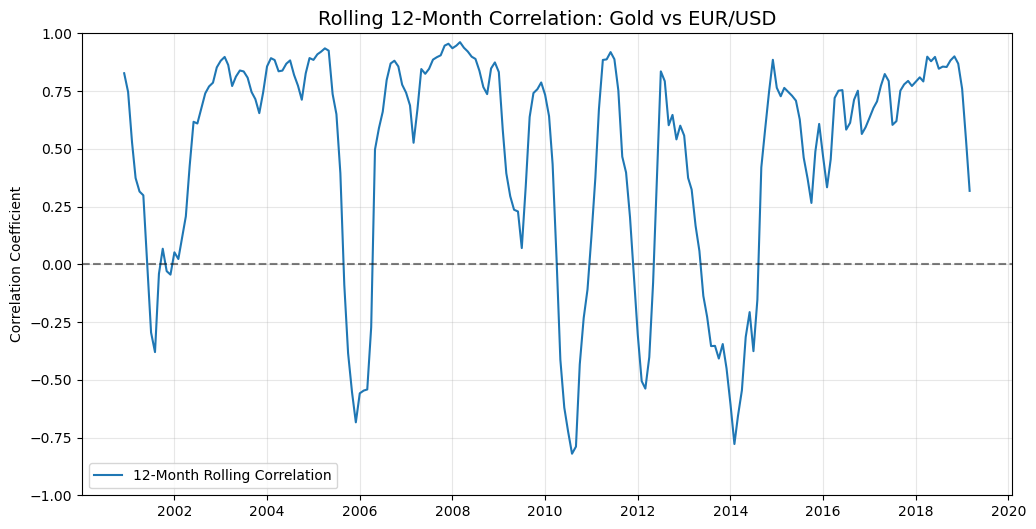

In [14]:
#Calculate the rolling correlation (12-month window)
rolling_corr = data['Gold'].rolling(window=12).corr(data['EURUSD'])

#Plot result
plt.figure(figsize=(12, 6))
plt.plot(rolling_corr.index.to_timestamp(), rolling_corr, label='12-Month Rolling Correlation')

#Add a reference line at 0 (No Correlation)
plt.axhline(0, color='black', linestyle='--', alpha=0.5)

# 4. Styling
plt.title('Rolling 12-Month Correlation: Gold vs EUR/USD', fontsize=14)
plt.ylabel('Correlation Coefficient')
plt.ylim(-1, 1)
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


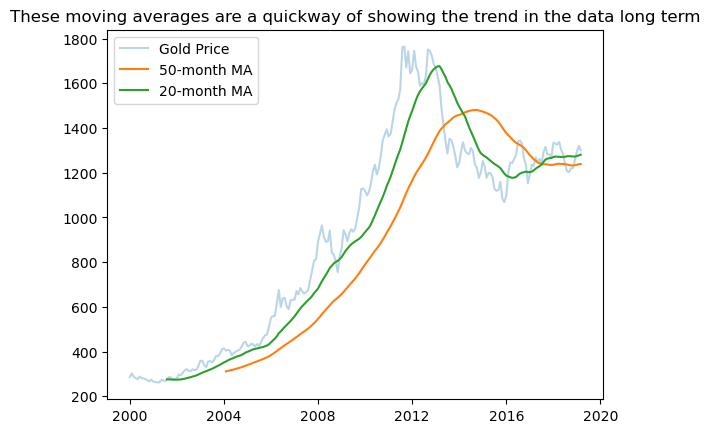

In [15]:
#Long-term trend determination
#Either you can use rolling mean or a moving average

#Moving average (MA)
data['GoldMA_50'] = data['Gold'].rolling(window=50).mean()
data['GoldMA_20'] = data['Gold'].rolling(window=20).mean()
#Use .index.to_timestamp() for the x-axis
plt.plot(data.index.to_timestamp(), data['Gold'], alpha=0.3, label='Gold Price')
plt.plot(data.index.to_timestamp(), data['GoldMA_50'], label='50-month MA')
plt.plot(data.index.to_timestamp(), data['GoldMA_20'], label='20-month MA')
plt.title("These moving averages are a quickway of showing the trend in the data long term")
plt.legend()
plt.show()


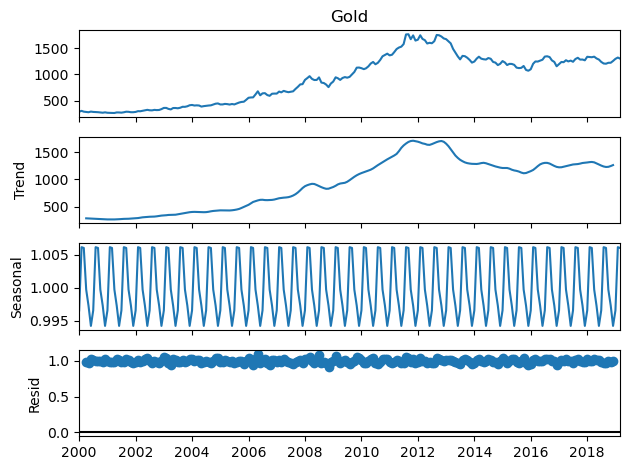

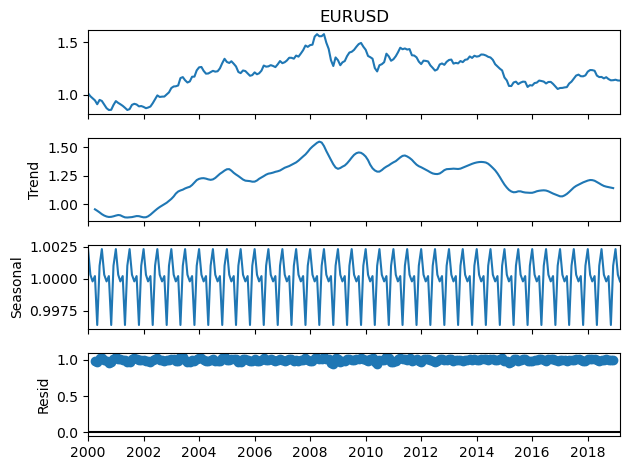

In [16]:
#lets perform some seasonal decomposition

from statsmodels.tsa.seasonal import seasonal_decompose

#convert index to timestamps before decomposing
data.index = data.index.to_timestamp()
result = seasonal_decompose(data['Gold'], model = 'multiplicative', period=6)
result2 = seasonal_decompose(data['EURUSD'], model = 'multiplicative', period=6)
result.plot();
result2.plot();

In [17]:
Gold_residuals = result.resid
EURUSD_residuals = result2.resid

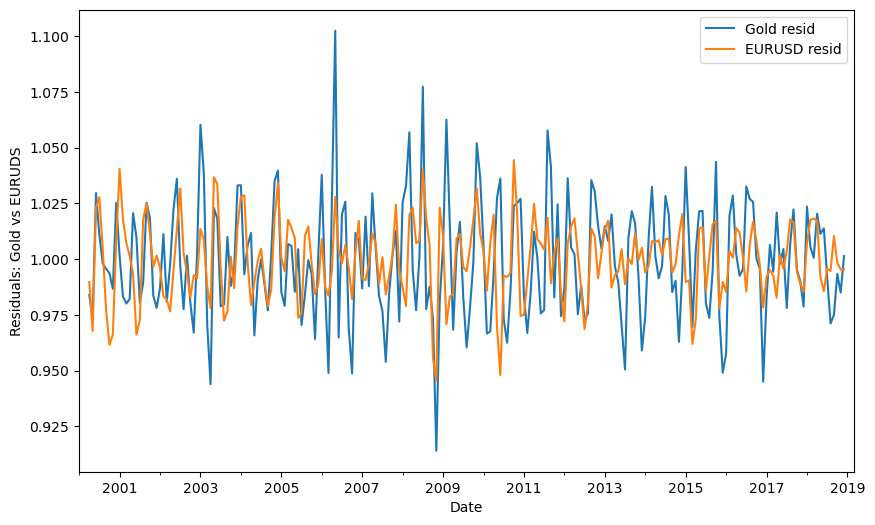

In [18]:
plt.figure(figsize=(10, 6))
Gold_residuals.plot(label='Gold resid')
EURUSD_residuals.plot(label='EURUSD resid')
plt.ylabel('Residuals: Gold vs EURUDS')
plt.legend()

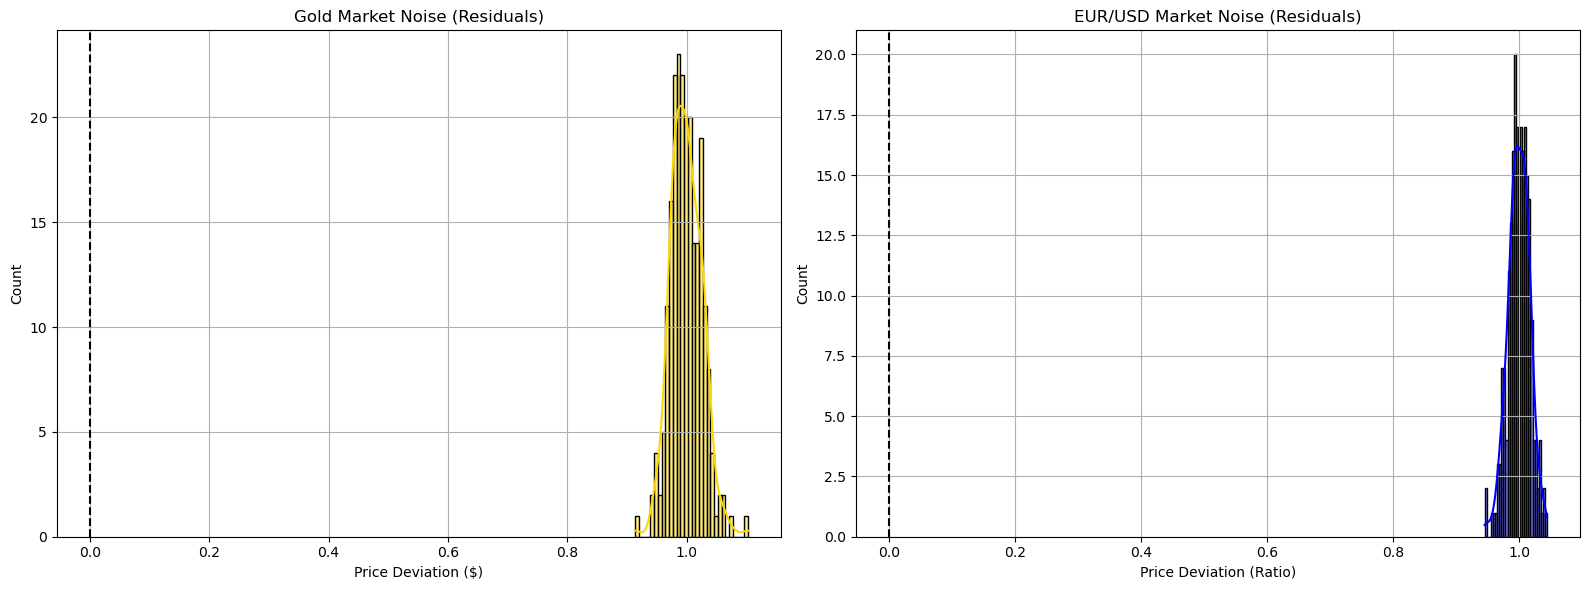

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Clean the residuals
Gold_residuals = result.resid.dropna()
EURUSD_residuals = result2.resid.dropna()

# 2. Create a side-by-side layout (1 row, 2 columns)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# 3. Plot Gold Residuals
sns.histplot(Gold_residuals, bins=30, kde=True, color='gold', ax=ax1)
ax1.axvline(0, color='black', linestyle='--')
ax1.set_title('Gold Market Noise (Residuals)')
ax1.set_xlabel('Price Deviation ($)')
ax1.grid()

# 4. Plot EUR/USD Residuals
sns.histplot(EURUSD_residuals, bins=30, kde=True, color='blue', ax=ax2)
ax2.axvline(0, color='black', linestyle='--')
ax2.set_title('EUR/USD Market Noise (Residuals)')
ax2.set_xlabel('Price Deviation (Ratio)')
ax2.grid()

plt.tight_layout() # Prevents labels from overlapping
plt.show()


In [20]:
# PROJECT 2: Gold Volatility and Risk

In [21]:
import yfinance as yf
gold = yf.download("GC=F", start="2000-01-01", end="2026-03-19") #the GC=F is the silver ticker under yahoo finance
gold = gold.dropna()
gold

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,GC=F,GC=F,GC=F,GC=F,GC=F
Date,,,,,
2000-08-30,273.899994,273.899994,273.899994,273.899994,0
2000-08-31,278.299988,278.299988,274.799988,274.799988,0
2000-09-01,277.000000,277.000000,277.000000,277.000000,0
2000-09-05,275.799988,275.799988,275.799988,275.799988,2
2000-09-06,274.200012,274.200012,274.200012,274.200012,0
...,...,...,...,...,...
2026-03-13,5052.500000,5117.000000,5009.500000,5089.600098,479
2026-03-16,4994.000000,5010.600098,4994.000000,5001.600098,130


In [22]:
silver = yf.download("SI=F", start="2000-01-01", end="2026-03-19") #the SI=F is the silver ticker under yahoo finance
silver = silver.dropna()
silver

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,SI=F,SI=F,SI=F,SI=F,SI=F
Date,,,,,
2000-08-30,4.930000,4.950000,4.895000,4.950000,2319
2000-08-31,5.003000,5.045000,4.920000,4.920000,1612
2000-09-01,5.004000,5.035000,4.985000,5.035000,1375
2000-09-05,4.998000,5.005000,4.975000,4.990000,856
2000-09-06,4.983000,5.000000,4.980000,5.000000,232
...,...,...,...,...,...
2026-03-13,80.914001,83.815002,79.449997,82.000000,856
2026-03-16,80.263000,80.904999,79.000000,79.000000,91


In [23]:
DXY = yf.download("DX-Y.NYB", start="2000-01-01", end="2026-03-19") #the DX-Y.NYB is the silver ticker under yahoo finance
DXY = DXY.dropna()
DXY

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB,DX-Y.NYB
Date,,,,,
2000-01-03,100.220001,101.830002,100.190002,101.669998,0
2000-01-04,100.410004,100.860001,100.010002,100.550003,0
2000-01-05,100.379997,100.470001,99.709999,100.419998,0
2000-01-06,100.650002,100.809998,99.809998,100.309998,0
2000-01-07,100.800003,100.930000,100.440002,100.489998,0
...,...,...,...,...,...
2026-03-12,99.739998,99.760002,99.250000,99.449997,0
2026-03-13,100.360001,100.540001,99.589996,99.690002,0


In [24]:
USOIL = yf.download("CL=F", start="2000-01-01", end="2026-03-19") #the DX-Y.NYB is the dollar index ticker under yahoo finance
USOIL = USOIL.dropna()
USOIL

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,CL=F,CL=F,CL=F,CL=F,CL=F
Date,,,,,
2000-08-23,32.049999,32.799999,31.950001,31.950001,79385
2000-08-24,31.629999,32.240002,31.400000,31.900000,72978
2000-08-25,32.049999,32.099998,31.320000,31.700001,44601
2000-08-28,32.869999,32.919998,31.860001,32.040001,46770
2000-08-29,32.720001,33.029999,32.560001,32.820000,49131
...,...,...,...,...,...
2026-03-13,98.709999,99.320000,92.040001,96.739998,436700
2026-03-16,93.500000,102.440002,92.930000,100.930000,455454


In [25]:
print(gold.columns)
print(silver.columns)
print(DXY.columns)
print(USOIL.columns)

MultiIndex([( 'Close', 'GC=F'),
            (  'High', 'GC=F'),
            (   'Low', 'GC=F'),
            (  'Open', 'GC=F'),
            ('Volume', 'GC=F')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', 'SI=F'),
            (  'High', 'SI=F'),
            (   'Low', 'SI=F'),
            (  'Open', 'SI=F'),
            ('Volume', 'SI=F')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', 'DX-Y.NYB'),
            (  'High', 'DX-Y.NYB'),
            (   'Low', 'DX-Y.NYB'),
            (  'Open', 'DX-Y.NYB'),
            ('Volume', 'DX-Y.NYB')],
           names=['Price', 'Ticker'])
MultiIndex([( 'Close', 'CL=F'),
            (  'High', 'CL=F'),
            (   'Low', 'CL=F'),
            (  'Open', 'CL=F'),
            ('Volume', 'CL=F')],
           names=['Price', 'Ticker'])


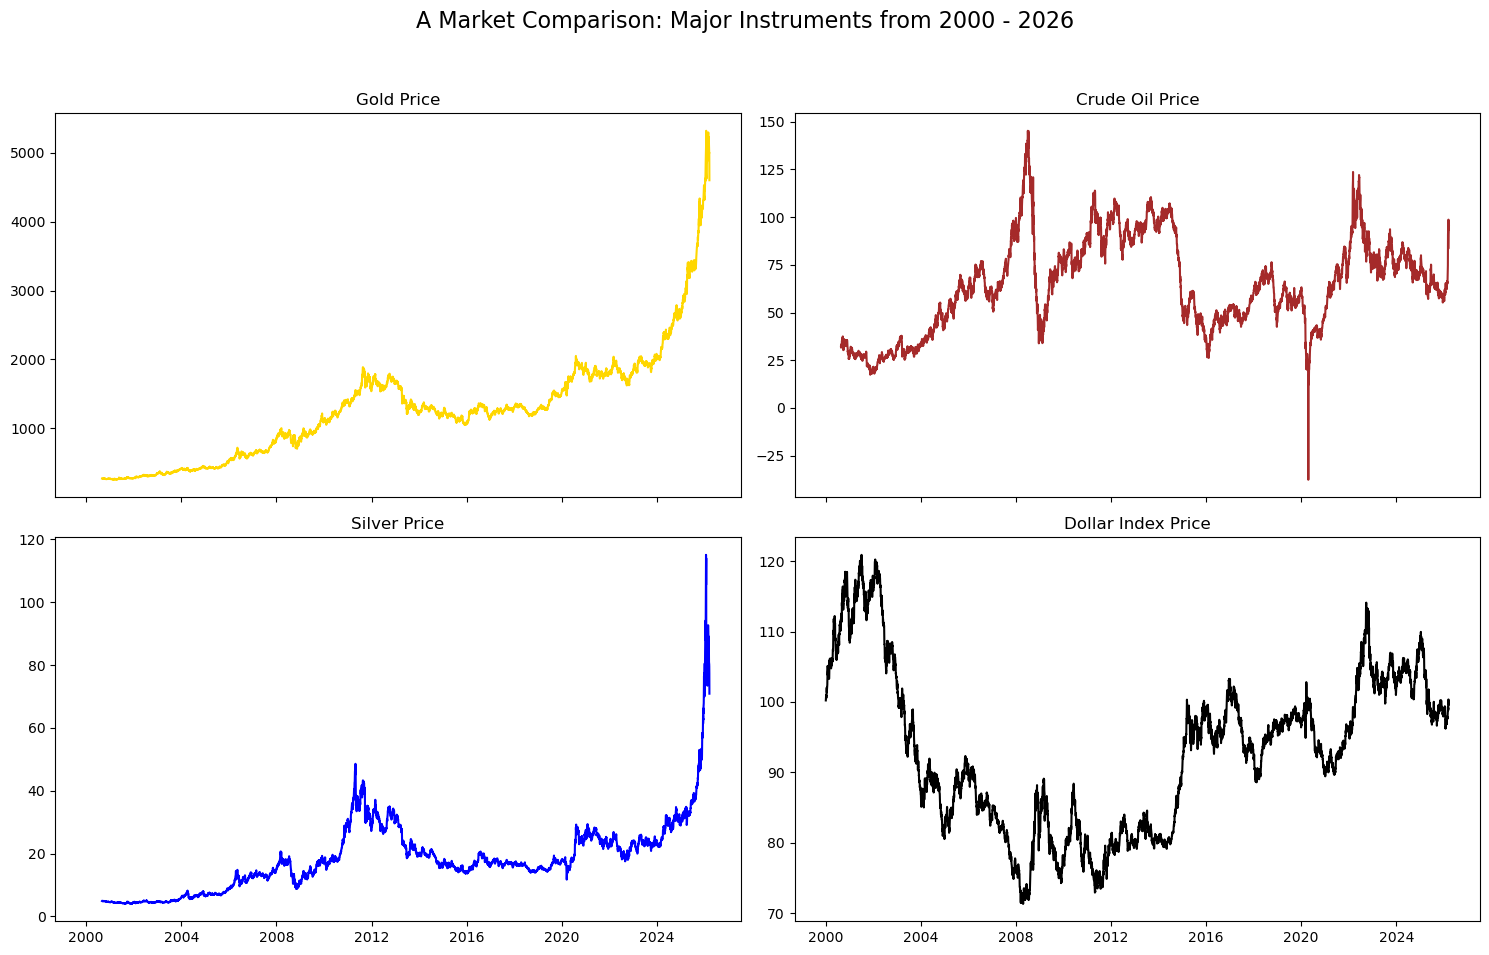

In [26]:
import matplotlib.pyplot as plt

# 1. Create the 2x2 layout
# sharex=True aligns the dates vertically so they are easier to read
fig, axs = plt.subplots(2, 2, figsize=(15, 10), sharex=True)

# --- TOP LEFT: Gold Trend ---
axs[0, 0].plot(gold.index, gold[['Close']], color='gold')
axs[0, 0].set_title('Gold Price')

# --- TOP RIGHT: EUR/USD Trend ---
axs[0, 1].plot(USOIL.index, USOIL[['Close']], color='brown')
axs[0, 1].set_title('Crude Oil Price')

# --- BOTTOM LEFT: Gold Seasonal ---
axs[1, 0].plot(silver.index, silver[['Close']], color='blue', label='XAG')
axs[1, 0].set_title('Silver Price')

# --- BOTTOM RIGHT: EUR/USD Seasonal ---
axs[1, 1].plot(DXY.index, DXY[['Close']], color='black', label='DXY')
axs[1, 1].set_title('Dollar Index Price')

# 2. Add a main title for the whole window
fig.suptitle('A Market Comparison: Major Instruments from 2000 - 2026', fontsize=16)

# 3. Fix layout so titles don't hit the axis labels
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) 
plt.show()


In [28]:
# Measuring volatility
# Volatility is a a measure in the standard deviantion of risk/returns.
# AI advice: never measure volatility on raw data.

import numpy as np
# 1.
gold_volatility = gold['Close'].pct_change().std() # this is daily volatility
oil_volatility = USOIL['Close'].pct_change().std()
dxy_volatility = np.log(DXY['Close']/DXY['Close'].shift(1)).std()

In [29]:
# 2. rolling volatitlity
#shows how volatility changes with time

gold_rol_volatility = gold['Close'].pct_change().rolling(window=30).std() #30 day window
oil_rol_volatility = USOIL['Close'].pct_change().rolling(window=30).std()
dxy_rol_volatility = DXY['Close'].pct_change().rolling(window=30).std()

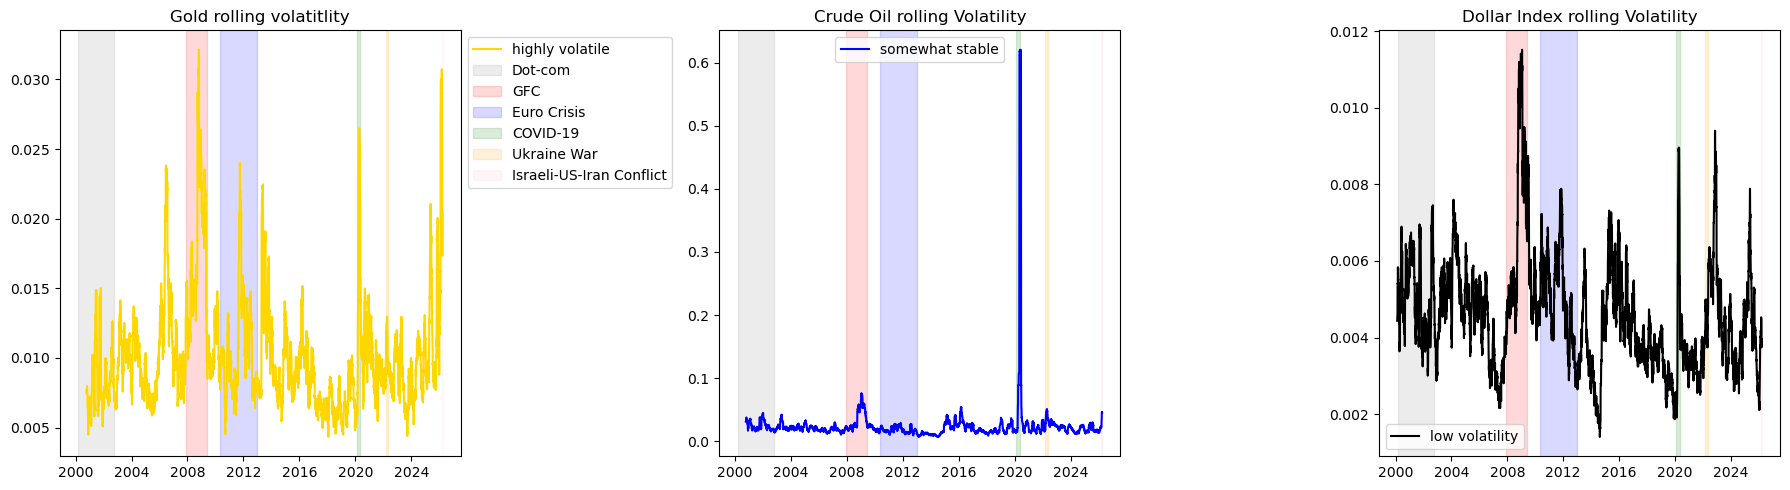

In [30]:
def add_crisis_shading(ax):
    """Adds shaded regions for major economic crises to a given axis."""
    crises = [
        ("Dot-com", "2000-03-01", "2002-10-01", "gray"),
        ("GFC", "2007-12-01", "2009-06-01", "red"),
        ("Euro Crisis", "2010-05-01", "2012-12-31", "blue"),
        ("COVID-19", "2020-02-01", "2020-04-30", "green"),
        ("Ukraine War", "2022-02-24", "2022-04-30", "orange"),
        ("Israeli-US-Iran Conflict", "2026-02-28", "2026-03-16", "pink")
    ]
    
    for name, start, end, color in crises:
        ax.axvspan(pd.to_datetime(start), pd.to_datetime(end), 
                   color=color, alpha=0.15, label=name)

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(18, 5))

ax1.plot(gold_rol_volatility, color='gold', label='highly volatile')
ax1.set_title('Gold rolling volatitlity')
ax1.legend()

ax2.plot(oil_rol_volatility, color='blue', label='somewhat stable')
ax2.set_title('Crude Oil rolling Volatility')
ax2.legend()

ax3.plot(dxy_rol_volatility, color='black', label='low volatility')
ax3.set_title('Dollar Index rolling Volatility')
ax3.legend()

for ax in [ax1, ax2, ax3]:
    add_crisis_shading(ax)

# Only show the legend once to keep it clean
ax1.legend(loc='upper left', bbox_to_anchor=(1, 1))
plt.tight_layout()
plt.show()



In [31]:
# Project 3: Building a regression model

# To build a regression model, we need a set of variables to use: DXY, USOIL, S&P500, CPI NFP FOMC -data.
# These are the variables i'll be using to make a model Gold and Silver data

In [54]:
#Data Collection
# 1. Market data
import yfinance as yf

gold = yf.download("GC=F", start="2000-01-01", end="2026-03-19")
silver = yf.download("SI=F", start="2000-01-01", end="2026-03-19")
DXY = yf.download("DX-Y.NYB", start="2000-01-01", end="2026-03-19")
oil = yf.download("CL=F", start="2000-01-01", end="2026-03-19")
sp500 = yf.download("^GSPC", start="2000-01-01", end="2026-03-19")

# 2. Macro-data (FRED - Federeal Reserve Economic Data)
from pandas_datareader import data as pdr

CPI = pdr.DataReader("CPIAUCSL", "fred", start="2000-01-01", end="2026-03-19") # Consumer Price Index: measures infaltion
CPI = CPI.dropna()
FOMC = pdr.DataReader("FEDFUNDS", "fred", start="2000-01-01", end="2026-03-19") # Federal Open Market Committe: interest rates
FOMC = FOMC.dropna()
NFP = pdr.DataReader("PAYEMS", "fred", start="2000-01-01", end="2026-03-19") # Non-Farm Payrolls: employment
NFP = NFP.dropna()

[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


In [96]:
# Prep Data and convert to returns
gold = gold[['Close']]
#gold['Close'] = pd.to_numeric(gold[['Close']], errors='coerce')
gold['return'] = np.log(gold['Close']/gold['Close'].shift(1))

silver = silver[['Close']]
#silver['Close'] = pd.to_numeric(silver['Close'], errors='coerce')
silver['return'] = np.log(silver['Close']/silver['Close'].shift(1))

DXY = DXY[['Close']]
#DXY['Close'] = pd.to_numeric(DXY['Close'], errors='coerce')
DXY['return'] = np.log(DXY['Close']/DXY['Close'].shift(1))

oil = oil[['Close']]
#oil['Close'] = pd.to_numeric(oil['Close'], errors='coerce')
oil['return'] = np.log(oil['Close']/oil['Close'].shift(1))

sp500 = sp500[['Close']]
#sp500['Close'] = pd.to_numeric(sp500['Close'], errors='coerce')
sp500['return'] = np.log(sp500['Close']/sp500['Close'].shift(1))

/home/user/miniconda3/envs/py39/lib/python3.9/site-packages/pandas/core/internals/blocks.py:351: RuntimeWarning: invalid value encountered in log
  result = func(self.values, **kwargs)


In [98]:
# Convert Macro data to % Change and Resample to daily to match the market data
CPI['cpi_change'] = CPI['cpi_change'].pct_change()
CPI = CPI.resample('D').ffill()
FOMC['fomc_change'] = FOMC['fomc_change'].pct_change()
FOMC = FOMC.resample('D').ffill()
NFP['nfp_change'] = NFP['nfp_change'].pct_change()
NFP = NFP.resample('D').ffill()

In [99]:
# Merge Macro and Market data

full_data = pd.concat([gold['return'], silver['return'], DXY['return'], oil['return'], sp500['return'],
                      CPI['cpi_change'], FOMC['fomc_change'], NFP['nfp_change']], axis=1)
full_data.columns = ['gold_return', 'silver_return', 'DXY_return', 'oil_return', 'sp500_return',
                    'cpi', 'fomc', 'nfp']
#full_data = full_data.dropna()

In [100]:
# Add lag features and volatility

full_data['gold_lag1'] = full_data['gold_return'].shift(1)
full_data['gold_lag2'] = full_data['gold_return'].shift(2)
full_data['silver_lag1'] = full_data['silver_return'].shift(1)
full_data['silver_lag2'] = full_data['silver_return'].shift(2)

full_data['gold_vol'] = full_data['gold_return'].rolling(window=30).std() #volatility at a 30-day window
full_data['silver_vol'] = full_data['silver_return'].rolling(window=30).std()

In [118]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

#choose your predictor(s)
X = full_data[['DXY_return', 'oil_return', 'sp500_return', 'cpi', 'fomc', 'nfp', 'gold_lag1']].copy()
y = full_data['gold_return'].copy()

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Combine using matching index
model_data = pd.concat([X, y], axis=1)

print("Before dropna:", model_data.shape)
print(model_data.isna().sum())

model_data = model_data.dropna()

print("After dropna:", model_data.shape)
print(model_data.head())

# Stop early if empty
if model_data.empty:
    raise ValueError("No valid rows left after cleaning. Check X, y, and index alignment.")

X_clean = model_data[X.columns]
y_clean = model_data['gold_return']

X_clean = sm.add_constant(X_clean)

gold_model = sm.OLS(y_clean, X_clean).fit()
print(gold_model.summary())

Before dropna: (9562, 8)
DXY_return      2943
oil_return      3145
sp500_return    2972
cpi              219
fomc            2501
nfp               96
gold_lag1       3153
gold_return     3152
dtype: int64
After dropna: (3621, 8)
            DXY_return  oil_return  sp500_return  cpi  fomc  nfp  gold_lag1  \
2000-09-06    0.015098    0.033458     -0.009889  0.0   0.0  0.0  -0.004342   
2000-09-07   -0.004127    0.010814      0.006852  0.0   0.0  0.0  -0.005818   
2000-09-08    0.006053   -0.047235     -0.005345  0.0   0.0  0.0  -0.000730   
2000-09-12   -0.001735   -0.025975     -0.004894  0.0   0.0  0.0  -0.000732   
2000-09-13    0.001475   -0.011765      0.001968  0.0   0.0  0.0  -0.000733   

            gold_return  
2000-09-06    -0.005818  
2000-09-07    -0.000730  
2000-09-08    -0.002558  
2000-09-12    -0.000733  
2000-09-13    -0.000367  
                            OLS Regression Results                            
Dep. Variable:            gold_return   R-squared:          

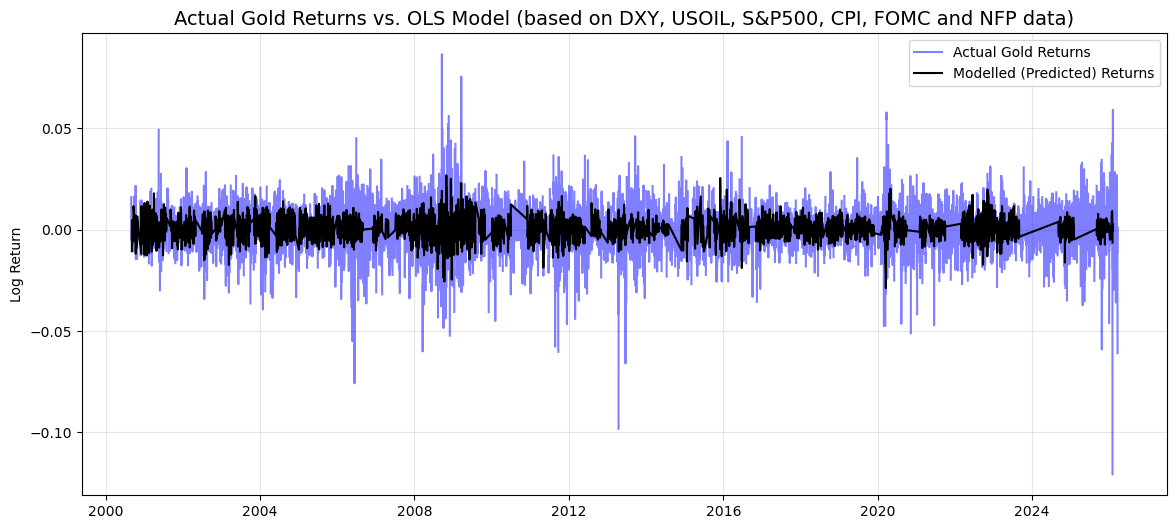

In [119]:
# 1. Get the predictions (modelled returns)
# Note: fittedvalues only exists for the rows used in the model
gold_modelled = gold_model.fittedvalues

# 2. Plot Actual vs Modelled
plt.figure(figsize=(14, 6))

# Plot Actual (The 'y' you used in the model)
plt.plot(y.index, y.values, 
         label='Actual Gold Returns', color='blue', alpha=0.5)

# Plot Modelled (The 'fitted values')
plt.plot(gold_modelled.index, gold_modelled.values, 
         label='Modelled (Predicted) Returns', color='black', linewidth=1.5)

# 3. Styling
plt.title('Actual Gold Returns vs. OLS Model (based on DXY, USOIL, S&P500, CPI, FOMC and NFP data)', fontsize=14)
plt.ylabel('Log Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


In [120]:
import numpy as np
import pandas as pd
import statsmodels.api as sm

#choose your predictor(s)
X = full_data[['DXY_return', 'oil_return', 'sp500_return', 'cpi', 'fomc', 'nfp', 'silver_lag1']].copy()
y = full_data['silver_return'].copy()

# Convert everything to numeric
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Replace inf with NaN
X = X.replace([np.inf, -np.inf], np.nan)
y = y.replace([np.inf, -np.inf], np.nan)

# Combine using matching index
model_data = pd.concat([X, y], axis=1)

print("Before dropna:", model_data.shape)
print(model_data.isna().sum())

model_data = model_data.dropna()

print("After dropna:", model_data.shape)
print(model_data.head())

# Stop early if empty
if model_data.empty:
    raise ValueError("No valid rows left after cleaning. Check X, y, and index alignment.")

X_clean = model_data[X.columns]
y_clean = model_data['silver_return']

X_clean = sm.add_constant(X_clean)

gold_model = sm.OLS(y_clean, X_clean).fit()
print(gold_model.summary())

Before dropna: (9562, 8)
DXY_return       2943
oil_return       3145
sp500_return     2972
cpi               219
fomc             2501
nfp                96
silver_lag1      3151
silver_return    3150
dtype: int64
After dropna: (3621, 8)
            DXY_return  oil_return  sp500_return  cpi  fomc  nfp  silver_lag1  \
2000-09-06    0.015098    0.033458     -0.009889  0.0   0.0  0.0    -0.001200   
2000-09-07   -0.004127    0.010814      0.006852  0.0   0.0  0.0    -0.003006   
2000-09-08    0.006053   -0.047235     -0.005345  0.0   0.0  0.0    -0.009679   
2000-09-12   -0.001735   -0.025975     -0.004894  0.0   0.0  0.0    -0.007749   
2000-09-13    0.001475   -0.011765      0.001968  0.0   0.0  0.0     0.004901   

            silver_return  
2000-09-06      -0.003006  
2000-09-07      -0.009679  
2000-09-08      -0.002435  
2000-09-12       0.004901  
2000-09-13      -0.003469  
                            OLS Regression Results                            
Dep. Variable:          silv

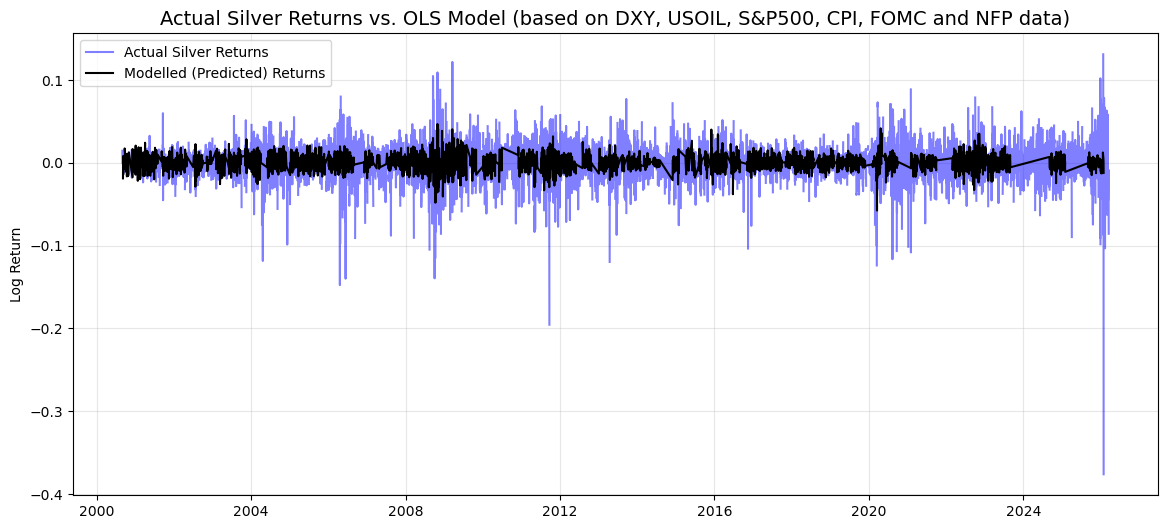

In [121]:
# 1. Get the predictions (modelled returns)
# Note: fittedvalues only exists for the rows used in the model
gold_modelled = gold_model.fittedvalues

# 2. Plot Actual vs Modelled
plt.figure(figsize=(14, 6))

# Plot Actual (The 'y' you used in the model)
plt.plot(y.index, y.values, 
         label='Actual Silver Returns', color='blue', alpha=0.5)

# Plot Modelled (The 'fitted values')
plt.plot(gold_modelled.index, gold_modelled.values, 
         label='Modelled (Predicted) Returns', color='black', linewidth=1.5)

# 3. Styling
plt.title('Actual Silver Returns vs. OLS Model (based on DXY, USOIL, S&P500, CPI, FOMC and NFP data)', fontsize=14)
plt.ylabel('Log Return')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
